In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_waw = pd.read_csv("data/warszawa-gus-bdl.csv", delimiter=";", decimal=",")
df_krk = pd.read_csv("data/krakow-gus-bdl.csv", delimiter=";", decimal=",")

lata = [str(rok) for rok in range(2016, 2025)]

def get_series(df, kat, grupa, podgrupa, wymiar1, wymiar2):
    mask = (df['Kategoria'] == kat) & \
           (df['Grupa'] == grupa) & \
           (df['Podgrupa (wymiary)'] == podgrupa) & \
           (df['Wymiar 1'] == wymiar1) & \
           (df['Wymiar 2'] == wymiar2)
    
    row = df[mask]
    if row.empty:
        print(f"Brak danych dla: {wymiar2}")
        return pd.Series(dtype=float)
    
    s = row[lata].iloc[0]
    if s.dtype == object:
        s = s.str.replace(',', '.').astype(float)
    return s

### ANALIZA MAKROEKONOMICZNA I KONDYCJA FINANSOWA (SALDO BUDŻETU)

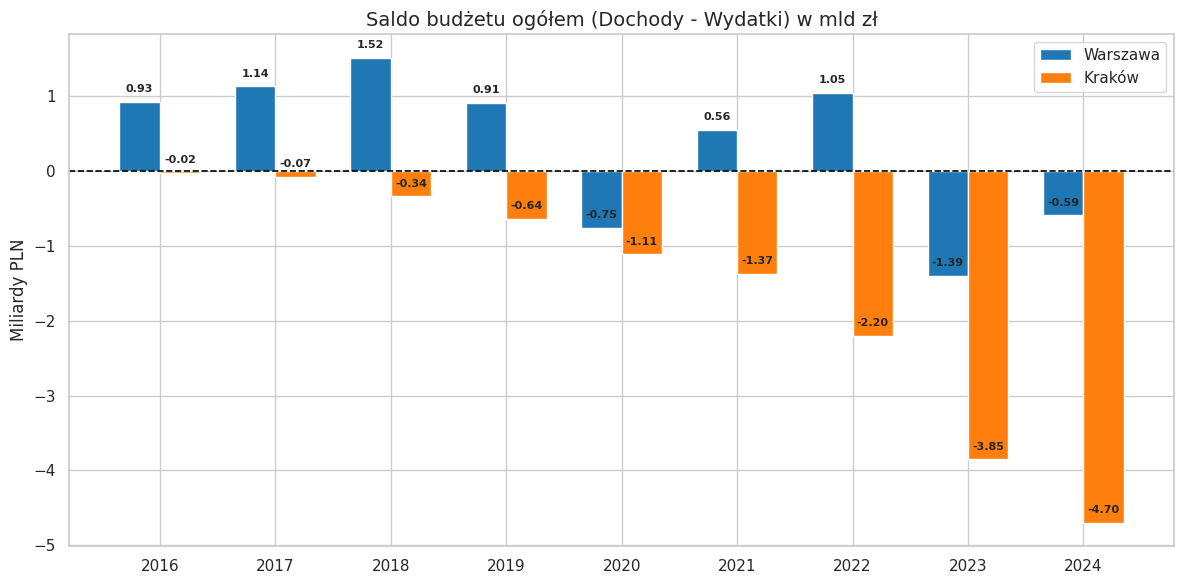

In [4]:
income_loc = ["FINANSE PUBLICZNE", "DOCHODY BUDŻETÓW GMIN I MIAST NA PRAWACH POWIATU", "Dochody ogółem (Wymiary: Jednostki terytorialne; Dochody)", "miasta na prawach powiatu", "ogółem"]
expenses_loc = ["FINANSE PUBLICZNE", "WYDATKI BUDŻETÓW GMIN I MIAST NA PRAWACH POWIATU", "Wydatki z budżetu ogółem (Wymiary: Jednostki terytorialne; Rodzaje wydatków)", "miasta na prawach powiatu", "ogółem"]

income_waw = get_series(df_waw, *income_loc).cumsum()
expenses_waw = get_series(df_waw, *expenses_loc).cumsum()
balance_waw = income_waw - expenses_waw

income_krk = get_series(df_krk, *income_loc).cumsum()
expenses_krk = get_series(df_krk, *expenses_loc).cumsum()
balance_krk = income_krk - expenses_krk

index = np.arange(len(lata))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(index, balance_waw.values / 1e9, bar_width, label='Warszawa', color='#1f77b4')
plt.bar(index + bar_width, balance_krk.values / 1e9, bar_width, label='Kraków', color='#ff7f0e')
for i in range(len(lata)):
    plt.text(index[i], balance_waw.values[i] / 1e9 + 0.1, f"{balance_waw.values[i]/1e9:.2f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.text(index[i] + bar_width, balance_krk.values[i] / 1e9 + 0.1, f"{balance_krk.values[i]/1e9:.2f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.xticks(index + bar_width / 2, lata)
plt.title('Saldo budżetu ogółem (Dochody - Wydatki) w mld zł', fontsize=14)
plt.ylabel('Miliardy PLN')
plt.legend()
plt.tight_layout()
plt.savefig("img/saldo_budzetu.png")
plt.show()

### KORELACJA: PIT PER CAPITA VS OŚWIATA PER CAPITA

In [5]:
INFLATION = [1.0, 1.02, 1.016, 1.023, 1.034, 1.051, 1.144, 1.114, 1.036]
inflation_multiplier = np.array(INFLATION).cumprod()
inflation_multiplier

array([1.        , 1.02      , 1.03632   , 1.06015536, 1.09620064,
       1.15210687, 1.31801026, 1.46826344, 1.52112092])

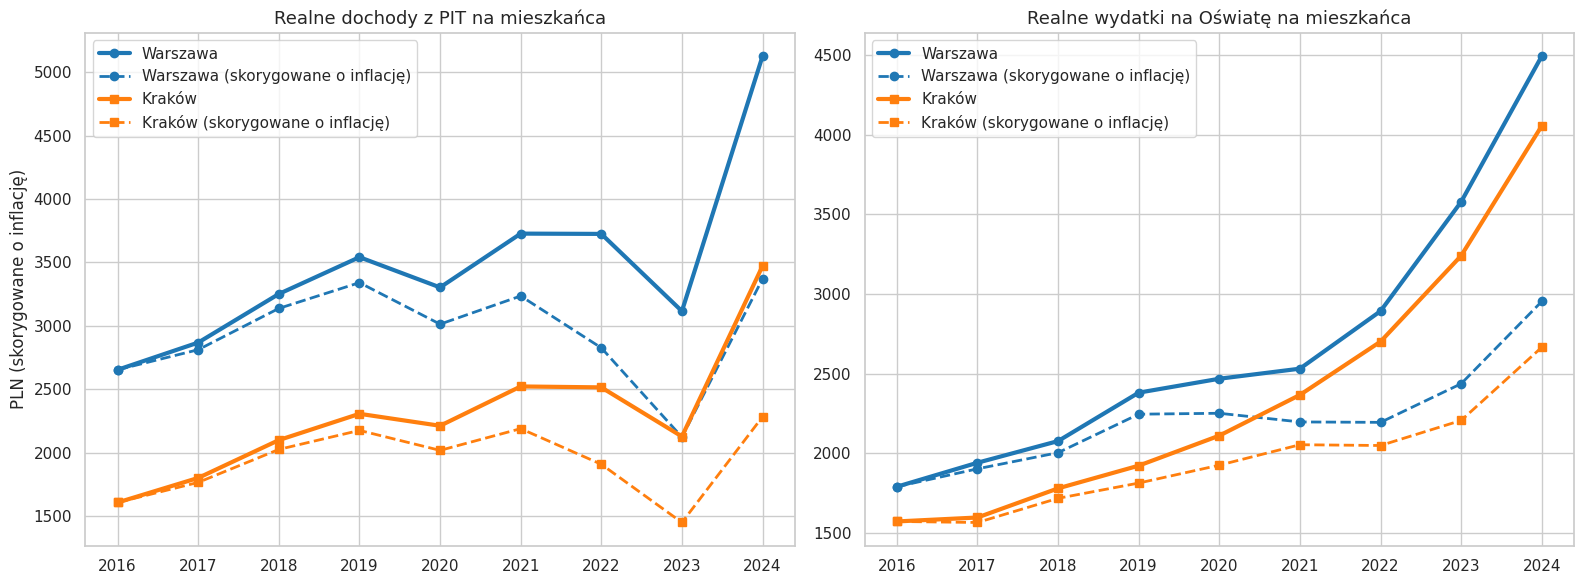

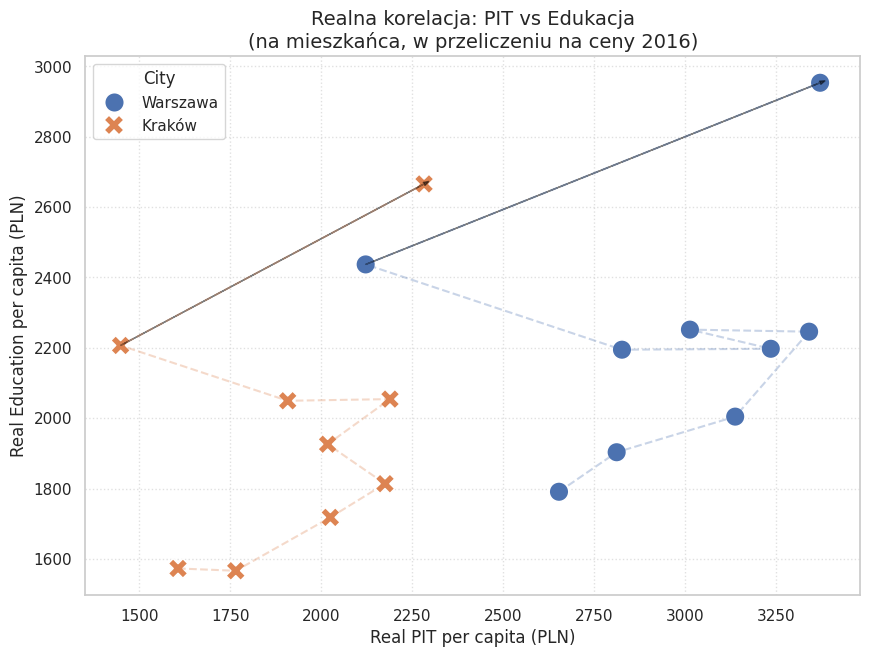

Correlation on REAL data (after removing inflation impact):
Warszawa: r = 0.250, p-value = 0.5171
Kraków: r = 0.361, p-value = 0.3401


In [ ]:
pit_pc_loc = ["FINANSE PUBLICZNE", "DOCHODY BUDŻETÓW GMIN I MIAST NA PRAWACH POWIATU", "Dochody na 1 mieszkańca (Wymiary: Jednostki terytorialne; Wskaźniki)", "miasta na prawach powiatu", "dochody własne - udziały w podatkach stanowiących dochody budżetu państwa podatek dochodowy od osób fizycznych"]
education_pc_loc = ["FINANSE PUBLICZNE", "WYDATKI BUDŻETÓW GMIN I MIAST NA PRAWACH POWIATU", "Wydatki na 1 mieszkańca (Wymiary: Jednostki terytorialne; Wskaźniki)", "miasta na prawach powiatu", "w Dziale 801- Oświata i wychowanie"]

pit_pc_waw = get_series(df_waw, *pit_pc_loc)
pit_pc_waw_inf = pit_pc_waw / inflation_multiplier
education_pc_waw = get_series(df_waw, *education_pc_loc)
education_pc_waw_inf = education_pc_waw / inflation_multiplier

pit_pc_krk = get_series(df_krk, *pit_pc_loc)
pit_pc_krk_inf = pit_pc_krk / inflation_multiplier
education_pc_krk = get_series(df_krk, *education_pc_loc)
education_pc_krk_inf = education_pc_krk / inflation_multiplier

# Preparing DataFrame for Seaborn plot
# df_corr = pd.DataFrame({
#     'PIT per capita': pd.concat([pit_pc_waw, pit_pc_krk]),
#     'Education per capita': pd.concat([education_pc_waw, education_pc_krk]),
#     'City': ['Warszawa']*len(lata) + ['Kraków']*len(lata)
# })

# sns.lmplot(data=df_corr, x='PIT per capita', y='Education per capita', hue='City', height=6, aspect=1.5, scatter_kws={'s': 80})
# plt.title('Correlation: PIT revenue vs Education spending (PLN per capita)', fontsize=14)
# plt.tight_layout()
# plt.show()

# # Calculating statistics
# for city, pit, edu in [('Warszawa', pit_pc_waw, education_pc_waw), ('Kraków', pit_pc_krk, education_pc_krk)]:
#     pearson_r, p_pearson = stats.pearsonr(pit.dropna(), edu.dropna())
#     spearman_rho, p_spearman = stats.spearmanr(pit.dropna(), edu.dropna())
#     print(f"{city}:")
#     print(f"  Pearson:  r = {pearson_r:.3f} (p-value = {p_pearson:.4f})")
#     print(f"  Spearman: rho = {spearman_rho:.3f} (p-value = {p_spearman:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# PIT plot
ax[0].plot(lata, pit_pc_waw, marker='o', label='Warszawa', linewidth=3, color='tab:blue')
ax[0].plot(lata, pit_pc_waw_inf, marker='o', label='Warszawa (skorygowane o inflację)', linewidth=2, linestyle='--', color='tab:blue')
ax[0].plot(lata, pit_pc_krk, marker='s', label='Kraków', linewidth=3, color='tab:orange')
ax[0].plot(lata, pit_pc_krk_inf, marker='s', label='Kraków (skorygowane o inflację)', linewidth=2, linestyle='--', color='tab:orange')
ax[0].set_title('Realne dochody z PIT na mieszkańca', fontsize=13)
ax[0].set_ylabel('zł (skorygowane o inflację względem 2016)')
ax[0].legend()

# Education plot
ax[1].plot(lata, education_pc_waw, marker='o', label='Warszawa', linewidth=3, color='tab:blue')
ax[1].plot(lata, education_pc_waw_inf, marker='o', label='Warszawa (skorygowane o inflację)', linewidth=2, linestyle='--', color='tab:blue')
ax[1].plot(lata, education_pc_krk, marker='s', label='Kraków', linewidth=3, color='tab:orange')
ax[1].plot(lata, education_pc_krk_inf, marker='s', label='Kraków (skorygowane o inflację)', linewidth=2, linestyle='--', color='tab:orange')
ax[1].set_title('Realne wydatki na Oświatę na mieszkańca', fontsize=13)
ax[1].legend()

plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: CORRELATION ON REAL DATA ---

df_real = pd.DataFrame({
    'PIT_Real': pd.concat([pit_pc_waw_inf, pit_pc_krk_inf]),
    'Education_Real': pd.concat([education_pc_waw_inf, education_pc_krk_inf]),
    'City': ['Warszawa']*9 + ['Kraków']*9,
    'Year': lata * 2
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_real, x='PIT_Real', y='Education_Real', hue='City', style='City', s=200)

# Adding trend arrows (showing how cities moved over time)
for city in ['Warszawa', 'Kraków']:
    temp = df_real[df_real['City'] == city]
    plt.plot(temp['PIT_Real'], temp['Education_Real'], alpha=0.3, linestyle='--')
    # Arrow at the end of the trend
    plt.arrow(temp['PIT_Real'].iloc[-2], temp['Education_Real'].iloc[-2], 
              temp['PIT_Real'].iloc[-1] - temp['PIT_Real'].iloc[-2], 
              temp['Education_Real'].iloc[-1] - temp['Education_Real'].iloc[-2], 
              head_width=10, color='black', alpha=0.5)

plt.title('Realna korelacja: PIT vs Edukacja\n(na mieszkańca, w przeliczeniu na ceny 2016)', fontsize=14)
plt.xlabel('Realny PIT na mieszkańca [zł]')
plt.ylabel('Realny wydatek na Edukację na mieszkańca [zł]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- STATISTICS ---
print("Correlation on REAL data (after removing inflation impact):")
for city in ['Warszawa', 'Kraków']:
    m = df_real[df_real['City'] == city]
    r, p = stats.pearsonr(m['PIT_Real'], m['Education_Real'])
    print(f"{city}: r = {r:.3f}, p-value = {p:.4f}")

### TEST T-STUDENTA (STRUKTURA WYDATKÓW - OŚWIATA)

Test t-Studenta dla % udziału wydatków na Oświatę w wydatkach ogółem:
  Średnia Warszawa: 8.05%
  Średnia Kraków:   8.97%
  Statystyka t: -0.308, p-value: 0.7625


/tmp/ipykernel_5627/220295614.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ttest, x='City', y='Share %', width=0.4, palette='Set2')


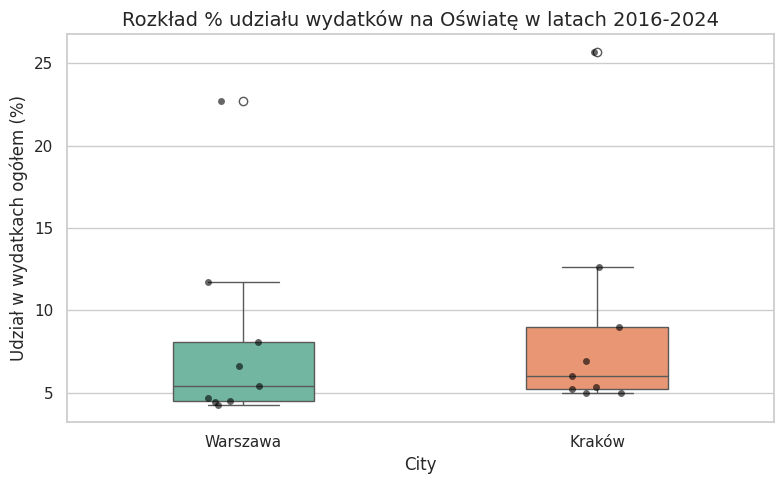

In [7]:
education_total_loc = ["FINANSE PUBLICZNE", "WYDATKI BUDŻETÓW GMIN I MIAST NA PRAWACH POWIATU", "Wydatki ogółem wg działów Klasyfikacji Budżetowej (Wymiary: Jednostki terytorialne; Działy klasyfikacji budżetowej)", "miasta na prawach powiatu", "Dział 801 - Oświata i wychowanie"]

education_total_waw = get_series(df_waw, *education_total_loc)
education_total_krk = get_series(df_krk, *education_total_loc)

# Calculating % share of education in total expenditures
education_share_waw = (education_total_waw / expenses_waw) * 100
education_share_krk = (education_total_krk / expenses_krk) * 100

# Student's t-test (Welch's t-test for unequal variances)
t_stat, p_val = stats.ttest_ind(education_share_waw.dropna(), education_share_krk.dropna(), equal_var=False)

print(f"Test t-Studenta dla % udziału wydatków na Oświatę w wydatkach ogółem:")
print(f"  Średnia Warszawa: {education_share_waw.mean():.2f}%")
print(f"  Średnia Kraków:   {education_share_krk.mean():.2f}%")
print(f"  Statystyka t: {t_stat:.3f}, p-value: {p_val:.4f}")

df_ttest = pd.DataFrame({
    'Share %': pd.concat([education_share_waw, education_share_krk]),
    'City': ['Warszawa']*len(lata) + ['Kraków']*len(lata)
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_ttest, x='City', y='Share %', width=0.4, palette='Set2')
sns.stripplot(data=df_ttest, x='City', y='Share %', color='black', alpha=0.6, jitter=True)
plt.title('Rozkład % udziału wydatków na Oświatę w latach 2016-2024', fontsize=14)
plt.ylabel('Udział w wydatkach ogółem (%)')
plt.tight_layout()
plt.show()

### ANALIZA SEKTOROWA

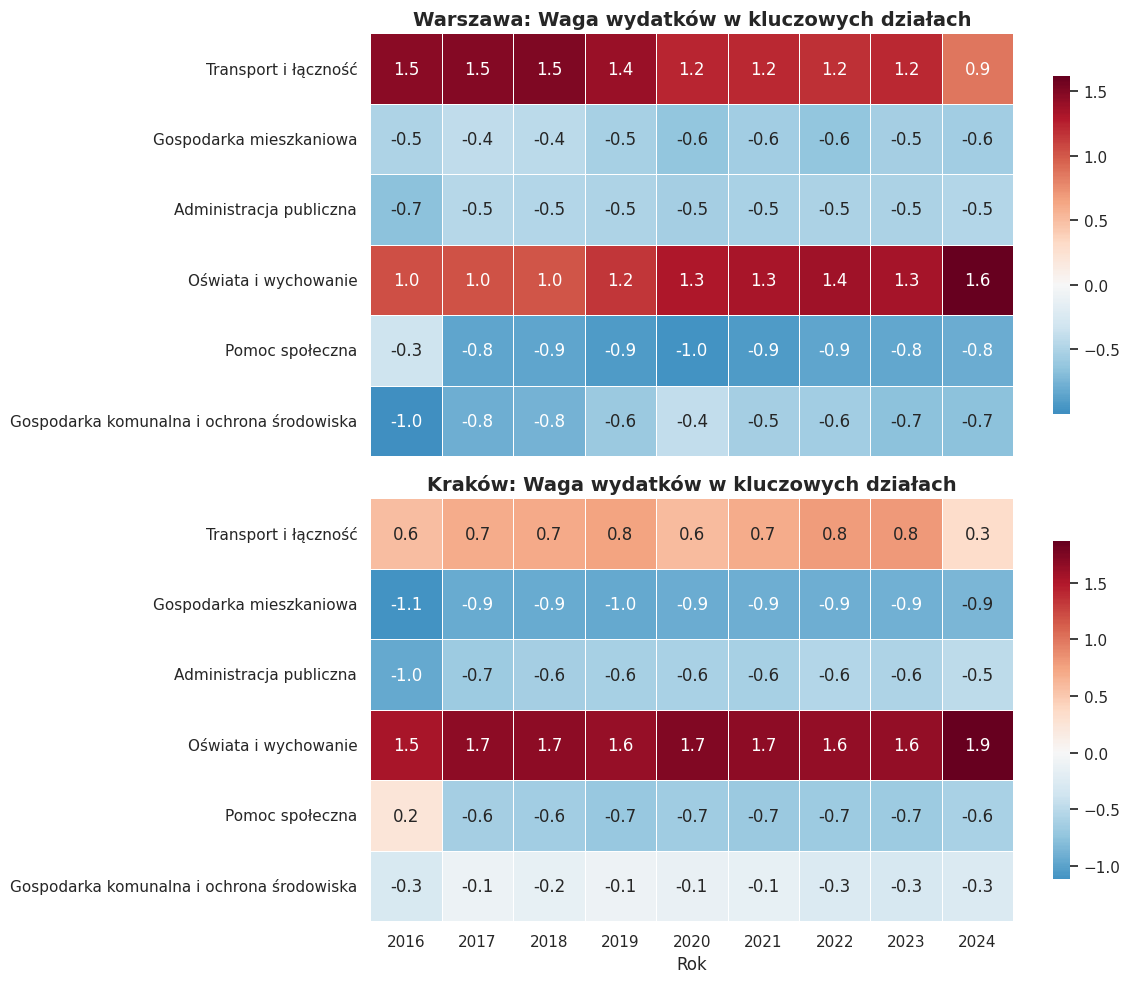

In [8]:
sections = [
    "Dział 600 - Transport i łączność",
    "Dział 700 - Gospodarka mieszkaniowa",
    "Dział 750 - Administracja publiczna",
    "Dział 801 - Oświata i wychowanie",
    "Dział 852 - Pomoc społeczna",
    "Dział 900 - Gospodarka komunalna i ochrona środowiska"
]

def get_sections(df_city):
    section_data = {}
    for section in sections:
        loc = [
            "FINANSE PUBLICZNE", 
            "WYDATKI BUDŻETÓW GMIN I MIAST NA PRAWACH POWIATU", 
            "Wydatki ogółem wg działów Klasyfikacji Budżetowej (Wymiary: Jednostki terytorialne; Działy klasyfikacji budżetowej)", 
            "miasta na prawach powiatu", 
            section
        ]
        # Extract series and ensure numeric (float)
        series = get_series(df_city, *loc)
        section_data[section.split(' - ')[1]] = pd.to_numeric(series, errors='coerce')
        
    return pd.DataFrame(section_data).T  # Sections as rows, years as columns

df_heatmap_waw = get_sections(df_waw)
df_heatmap_krk = get_sections(df_krk)

# SAFE Z-SCORE CALCULATION (pure Pandas)
# Z-score = (value - column mean) / column std
zscore_waw = df_heatmap_waw.sub(df_heatmap_waw.mean(axis=0), axis=1).div(df_heatmap_waw.std(axis=0), axis=1)
zscore_krk = df_heatmap_krk.sub(df_heatmap_krk.mean(axis=0), axis=1).div(df_heatmap_krk.std(axis=0), axis=1)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

sns.heatmap(zscore_waw, ax=axes[0], cmap='RdBu_r', center=0, annot=True, fmt=".1f", linewidths=.5, cbar_kws={"shrink": .8})
axes[0].set_title('Warszawa: Waga wydatków w kluczowych działach', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

sns.heatmap(zscore_krk, ax=axes[1], cmap='RdBu_r', center=0, annot=True, fmt=".1f", linewidths=.5, cbar_kws={"shrink": .8})
axes[1].set_title('Kraków: Waga wydatków w kluczowych działach', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Rok', fontsize=12)

plt.tight_layout()
plt.show()